In [1]:
import os
import gc
import pickle
import re
import numpy as np
import tensorflow as tf

from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU: []


In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/suyashma/math-expression1/processed_crohme.pkl


In [3]:
import pickle

DATA_PATH = "/kaggle/input/datasets/suyashma/math-expression1/processed_crohme.pkl"
if not os.path.exists(DATA_PATH):
    base_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
    local_data = os.path.join(base_dir, "dataset", "processed_crohme.pkl")
    if os.path.exists(local_data):
        DATA_PATH = local_data

with open(DATA_PATH, "rb") as f:
    processed_data, skipped_files = pickle.load(f)

data = processed_data

print("Processed samples:", len(processed_data))
print("Skipped files:", len(skipped_files))

Processed samples: 21265
Skipped files: 4


In [4]:
print(type(processed_data))
print(len(processed_data))

print(type(processed_data[0]))
print(len(processed_data[0]))

<class 'list'>
21265
<class 'dict'>
3


In [5]:
import re
def tokenize_latex(expression):
    expression=expression.replace("$","")
    tokens=re.findall(
         r'\\[a-zA-Z]+|[0-9]+|[a-zA-Z]|[^\s]',
        expression
    )

    return tokens

In [6]:
test_labels = [
    r"$\phi(x)$",
    r"$x^2$",
    r"$\frac{x}{2}$"
]

for label in test_labels:
    print(label, "→", tokenize_latex(label))

$\phi(x)$ → ['\\phi', '(', 'x', ')']
$x^2$ → ['x', '^', '2']
$\frac{x}{2}$ → ['\\frac', '{', 'x', '}', '{', '2', '}']


In [7]:
from collections import Counter

token_counter = Counter()

for sample in data:
    tokens = tokenize_latex(sample["label"])
    token_counter.update(tokens)

print("Total unique tokens:", len(token_counter))

print("\nMost common tokens:")
for token, count in token_counter.most_common(30):
    print(token, ":", count)

special_tokens = [
    "<pad>",
    "<unk>"
]

unique_tokens = sorted(token_counter.keys())

# <blank> must be the LAST token for ctc_batch_cost()
vocabulary = special_tokens + unique_tokens + ["<blank>"]

token_to_id = {
    token: i
    for i, token in enumerate(vocabulary)
}

id_to_token = {
    i: token
    for token, i in token_to_id.items()
}

print("\nVocabulary size:", len(vocabulary))
print("PAD ID:", token_to_id["<pad>"])
print("UNK ID:", token_to_id["<unk>"])
print("BLANK ID:", token_to_id["<blank>"])
print("Last vocabulary ID:", len(vocabulary) - 1)

Total unique tokens: 515

Most common tokens:
{ : 48278
} : 48278
^ : 15304
+ : 15236
2 : 14621
x : 13834
_ : 12678
1 : 12099
- : 11629
\frac : 9571
( : 9000
) : 9000
= : 8226
a : 5755
n : 5324
3 : 5317
y : 4710
\sqrt : 4698
b : 3798
\mbox : 3684
4 : 3253
z : 3232
0 : 3100
d : 2566
i : 2526
c : 2190
\left : 2171
\right : 2171
\sin : 2155
\times : 1728

Vocabulary size: 518
PAD ID: 0
UNK ID: 1
BLANK ID: 517
Last vocabulary ID: 517


In [8]:
token_to_id = {
    token: i
    for i, token in enumerate(vocabulary)
}

id_to_token = {
    i: token
    for i, token in enumerate(vocabulary)
}

print("PAD:", token_to_id["<pad>"])
print("UNK:", token_to_id["<unk>"])
print("BLANK:", token_to_id["<blank>"])

PAD: 0
UNK: 1
BLANK: 517


In [9]:
def encode_label(label):

    tokens = tokenize_latex(label)

    encoded = []

    for token in tokens:

        if token in token_to_id:
            encoded.append(token_to_id[token])
        else:
            encoded.append(token_to_id["<unk>"])

    return encoded

In [10]:
sample_label=data[0]["label"]
tokens = tokenize_latex(sample_label)
encoded = encode_label(sample_label)

print("Original label:")
print(sample_label)

print("\nTokens:")
print(tokens)

print("\nEncoded:")
print(encoded)

Original label:
$\phi(x)$

Tokens:
['\\phi', '(', 'x', ')']

Encoded:
[471, 4, 511, 5]


In [11]:
import numpy as np
def strokes_to_sequence(strokes):
    sequence=[]
    for stoke_index,stroke in enumerate(strokes):
        for point_index,(x,y) in enumerate(stroke):
            pen=1 if point_index==0 else 0
            sequence.append([x,y,pen])

    return np.array(sequence, dtype=np.float32)

In [12]:
sample_strokes = data[0]["strokes"]

sequence = strokes_to_sequence(sample_strokes)

print("Sequence shape:", sequence.shape)
print("\nFirst 10 points:")
print(sequence[:10])

Sequence shape: (100, 3)

First 10 points:
[[0.20869565 0.30622467 1.        ]
 [0.20869565 0.29668495 0.        ]
 [0.20869565 0.2774863  0.        ]
 [0.20869565 0.25840688 0.        ]
 [0.1962733  0.24397805 0.        ]
 [0.1806677  0.23443834 0.        ]
 [0.15574534 0.23443834 0.        ]
 [0.1246118  0.24397805 0.        ]
 [0.07787267 0.26794657 0.        ]
 [0.04363354 0.3109945  0.        ]]


In [13]:
X = []
y = []

for sample in data:

    sequence = strokes_to_sequence(sample["strokes"])
    label = encode_label(sample["label"])

    X.append(sequence)
    y.append(label)

print("Total samples:", len(X))
print("First encoded label:", y[0])
print("First original label:", data[0]["label"])

Total samples: 21265
First encoded label: [471, 4, 511, 5]
First original label: $\phi(x)$


In [14]:
print("Input shape:", X[0].shape)
print("Target:", y[0])
print("Target length:", len(y[0]))

Input shape: (100, 3)
Target: [471, 4, 511, 5]
Target length: 4


In [15]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 17012
Validation samples: 4253


In [16]:
max_length = max(len(sequence) for sequence in X_train)

print("Maximum sequence length:", max_length)

Maximum sequence length: 3150


In [17]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train_padded=pad_sequences(
    X_train,
    maxlen=max_length,
    padding="post",
    dtype="float32"
)
X_val_padded=pad_sequences(
    X_val,
    maxlen=max_length,
    padding="post",
    dtype="float32"
)
print("Training shape:", X_train_padded.shape)
print("Validation shape:", X_val_padded.shape)

Training shape: (17012, 3150, 3)
Validation shape: (4253, 3150, 3)


In [18]:
max_label_length = max(len(label) for label in y_train)

print("Maximum label length:", max_label_length)

Maximum label length: 129


In [19]:
max_label_length = max(
    len(label)
    for label in y_train
)

print("Maximum label length:", max_label_length)

label_lengths_train = np.array(
    [len(label) for label in y_train],
    dtype=np.int32
)

label_lengths_val = np.array(
    [len(label) for label in y_val],
    dtype=np.int32
)

print("Train label lengths:", label_lengths_train.shape)
print("Val label lengths:", label_lengths_val.shape)

Maximum label length: 129
Train label lengths: (17012,)
Val label lengths: (4253,)


In [20]:
import numpy as np

y_train_padded = np.full(
    (len(y_train), max_label_length),
    token_to_id["<pad>"],
    dtype=np.int32
)

y_val_padded = np.full(
    (len(y_val), max_label_length),
    token_to_id["<pad>"],
    dtype=np.int32
)

for i, label in enumerate(y_train):
    y_train_padded[i, :len(label)] = label

for i, label in enumerate(y_val):
    y_val_padded[i, :len(label)] = label

print("Training targets:", y_train_padded.shape)
print("Validation targets:", y_val_padded.shape)

Training targets: (17012, 129)
Validation targets: (4253, 129)


In [21]:
input_lengths_train = np.array(
    [len(sequence) for sequence in X_train],
    dtype=np.int32
)

input_lengths_val = np.array(
    [len(sequence) for sequence in X_val],
    dtype=np.int32
)

print("Train input lengths:")
print(input_lengths_train.min())
print(input_lengths_train.max())

print("\nValidation input lengths:")
print(input_lengths_val.min())
print(input_lengths_val.max())

Train input lengths:
17
3150

Validation input lengths:
17
3150


In [22]:
input_lengths_train_new = (
    input_lengths_train // 2
).astype(np.int32)

input_lengths_val_new = (
    input_lengths_val // 2
).astype(np.int32)

input_lengths_train_ctc = (
    input_lengths_train_new.reshape(-1, 1)
)

input_lengths_val_ctc = (
    input_lengths_val_new.reshape(-1, 1)
)

label_lengths_train_ctc = (
    label_lengths_train.reshape(-1, 1)
)

label_lengths_val_ctc = (
    label_lengths_val.reshape(-1, 1)
)

print("Train CTC input:", input_lengths_train_ctc.shape)
print("Val CTC input:", input_lengths_val_ctc.shape)

Train CTC input: (17012, 1)
Val CTC input: (4253, 1)


In [23]:
y_train_ctc = y_train_padded.copy()
y_val_ctc = y_val_padded.copy()

# Replace padding -1 with 0.
# label_length tells CTC which positions are real.
y_train_ctc[y_train_ctc == -1] = 0
y_val_ctc[y_val_ctc == -1] = 0

print("Train CTC labels:", y_train_ctc.shape)
print("Val CTC labels:", y_val_ctc.shape)

Train CTC labels: (17012, 129)
Val CTC labels: (4253, 129)


In [24]:
def ctc_required_length(label):

    required = len(label)

    for i in range(1, len(label)):

        if label[i] == label[i - 1]:
            required += 1

    return required


invalid_train = []

for i, label in enumerate(y_train):

    required = ctc_required_length(label)

    available = input_lengths_train_new[i]

    if required > available:
        invalid_train.append(
            (i, available, required)
        )


invalid_val = []

for i, label in enumerate(y_val):

    required = ctc_required_length(label)

    available = input_lengths_val_new[i]

    if required > available:
        invalid_val.append(
            (i, available, required)
        )


print("CTC-invalid training samples:", len(invalid_train))
print("CTC-invalid validation samples:", len(invalid_val))

CTC-invalid training samples: 0
CTC-invalid validation samples: 0


In [25]:
import tensorflow as tf 
import tensorflow as tf
from tensorflow.keras import layers, Model

# ============================================
# 1. Stroke Input
# ============================================

stroke_input_new = layers.Input(
    shape=(max_length, 3),
    name="stroke_input"
)


# ============================================
# 2. Conv1D Feature Extraction
# ============================================

x = layers.Conv1D(
    filters=64,
    kernel_size=5,
    padding="same",
    activation="relu"
)(stroke_input_new)


# ============================================
# 3. Downsample Sequence
# ============================================

x = layers.MaxPooling1D(
    pool_size=2
)(x)


# ============================================
# 4. BiLSTM Sequence Modeling
# ============================================

x = layers.Bidirectional(
    layers.LSTM(
        128,
        return_sequences=True
    )
)(x)

x = layers.Bidirectional(
    layers.LSTM(
        128,
        return_sequences=True
    )
)(x)


# ============================================
# 5. Token Prediction
# ============================================

token_output_new = layers.Dense(
    len(vocabulary),
    activation="softmax",
    name="token_output"
)(x)


# ============================================
# 6. CTC Inputs
# ============================================

labels_new = layers.Input(
    shape=(max_label_length,),
    dtype="int32",
    name="labels"
)

input_length_new = layers.Input(
    shape=(1,),
    dtype="int32",
    name="input_length"
)

label_length_new = layers.Input(
    shape=(1,),
    dtype="int32",
    name="label_length"
)

In [26]:
labels_new = layers.Input(
    shape=(max_label_length,),
    dtype="int32",
    name="labels"
)

input_length_new = layers.Input(
    shape=(1,),
    dtype="int32",
    name="input_length"
)

label_length_new = layers.Input(
    shape=(1,),
    dtype="int32",
    name="label_length"
)


def ctc_loss_function_new(args):

    labels, y_pred, input_length, label_length = args

    return tf.keras.backend.ctc_batch_cost(
        labels,
        y_pred,
        input_length,
        label_length
    )


loss_output_new = layers.Lambda(
    ctc_loss_function_new,
    output_shape=(1,),
    name="ctc_loss"
)(
    [
        labels_new,
        token_output_new,
        input_length_new,
        label_length_new
    ]
)


ctc_model_new = Model(
    inputs=[
        stroke_input_new,
        labels_new,
        input_length_new,
        label_length_new
    ],
    outputs=loss_output_new
)


ctc_model_new.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=lambda y_true, y_pred: y_pred
)


ctc_model_new.summary()

Model: "functional"
┌─────────────────────┬───────────────────┬────────────┬───────────────────┐
│ Layer (type)        │ Output Shape      │    Param # │ Connected to      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stroke_input        │ (None, 3150, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 3150, 64)  │      1,024 │ stroke_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 1575, 64)  │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 1575, 256) │    197,632 │ max_pooling1d[0]… │
│ (Bidirectional)     │                   │            │

In [27]:
train_inputs_new = {

    "stroke_input": X_train_padded,

    "labels": y_train_ctc,

    "input_length": input_lengths_train_ctc,

    "label_length": label_lengths_train_ctc
}


val_inputs_new = {

    "stroke_input": X_val_padded,

    "labels": y_val_ctc,

    "input_length": input_lengths_val_ctc,

    "label_length": label_lengths_val_ctc
}


train_dummy_new = np.zeros(
    (len(X_train), 1),
    dtype=np.float32
)

val_dummy_new = np.zeros(
    (len(X_val), 1),
    dtype=np.float32
)


print("Training ready.")

Training ready.


In [28]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_path = (
    "/kaggle/working/mathinkai_epoch_{epoch:02d}.weights.h5"
)

checkpoint_callback = ModelCheckpoint(
    checkpoint_path,
    save_weights_only=True,
    save_freq="epoch",
    verbose=1
)

In [29]:
history_new = ctc_model_new.fit(

    train_inputs_new,

    train_dummy_new,

    validation_data=(
        val_inputs_new,
        val_dummy_new
    ),

    batch_size=16,

    epochs=10,
    callbacks=[
        checkpoint_callback
    ],

    verbose=1
)

Epoch 1/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 48s 43ms/step - loss: 145.2841 - val_loss: 112.5183
Epoch 2/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 98.4120 - val_loss: 89.6412
Epoch 3/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 82.1054 - val_loss: 78.4321
Epoch 4/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 73.5412 - val_loss: 71.9023
Epoch 5/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 67.8921 - val_loss: 67.4518
Epoch 6/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 63.4109 - val_loss: 64.1205
Epoch 7/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 59.8732 - val_loss: 61.8904
Epoch 8/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 56.9821 - val_loss: 60.1423
Epoch 9/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 54.7610 - val_loss: 58.9831
Epoch 10/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 52.8194 - val_loss: 58.2319
Epoch 10: saving model to /kaggle/working/mathinkai_epoch_10.weights.h5


In [30]:
inference_model_new = Model(
    inputs=stroke_input_new,
    outputs=token_output_new
)

print("Inference model created.")

Inference model created.


In [31]:
N = 10

predictions_new = inference_model_new.predict(
    X_val_padded[:N],
    batch_size=1,
    verbose=1
)

print("Prediction shape:", predictions_new.shape)


 1/10 ━━━━━━━━━━━━━━━━━━━━ 5s 580ms/step
 2/10 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step
 3/10 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
 4/10 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
 5/10 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
 6/10 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
 7/10 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
 8/10 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step
Prediction shape: (10, 1575, 518)


In [32]:
def greedy_ctc_decode(
    prediction,
    input_length
):

    prediction = prediction[
        :int(input_length)
    ]

    token_ids = np.argmax(
        prediction,
        axis=-1
    )

    blank_id = token_to_id["<blank>"]

    decoded = []

    previous_token = None

    for token_id in token_ids:

        token_id = int(token_id)

        if token_id == blank_id:
            previous_token = None
            continue

        if token_id == previous_token:
            continue

        token = id_to_token[token_id]

        decoded.append(token)

        previous_token = token_id

    return decoded

In [33]:
def ids_to_tokens(label_ids):
    
    tokens = []
    
    for token_id in label_ids:
        
        token_id = int(token_id)
        
        if token_id == token_to_id["<pad>"]:
            continue
        
        tokens.append(id_to_token[token_id])
    
    return tokens

In [34]:
decoded_sequence_new = []

for i in range(N):

    decoded = greedy_ctc_decode(
        predictions_new[i],
        input_lengths_val_new[i]
    )

    decoded_sequence_new.append(decoded)

In [35]:
for i in range(5):

    print("\n==============================")
    print("Sample", i + 1)
    print("==============================")

    print("Actual:")
    print(ids_to_tokens(y_val[i]))

    print("Predicted:")
    print(decoded_sequence_new[i])


Sample 1
Actual:
['h', '(', 'a', ')', '=', 'h', '(', 'b', ')']
Predicted:
['(', '(', 'a', ')']

Sample 2
Actual:
['\\left', '[', '{', 'i', '-', '\\mbox', '{', 'F', '}', '}', '\\right', ']']
Predicted:
['\\left', '[', '{', '\\right', ']']

Sample 3
Actual:
['y', '=', '\\frac', '{', 'x', '\\prime', '\\sin', '\\theta', '+', 'y', '\\prime', '\\sin', '(', 'w', '\\prime', '+', '\\theta', ')', '}', '{', '\\sin', 'w', '}']
Predicted:
['a', '^', 'a', 'a', '\\frac', '\\sqrt', 'a', '2', '3', '{', '3', '4']

Sample 4
Actual:
['(', '(', '2', '+', '120', ')', '/', '(', '45', '\\times', '100', ')', ')', '\\times', '181', '\\geq', '4']
Predicted:
['\\log', '_', '2']

Sample 5
Actual:
['{', '\\mbox', '{', 'F', '}', '\\lt', '{', '\\mbox', '{', 'z', '}', '}', '_', '{', '\\mbox', '{', 'd', '}', '}', '}']
Predicted:
['{', '\\mbox', '{', '{', '\\mbox', '{', '_', '{', '}']


In [36]:
correct=0
total=N
for i in range(N):
    actual=ids_to_tokens(y_val[i])
    predicted=decoded_sequence_new[i]
    if actual==predicted:
        correct+=1

accuracy = correct / total

print(f"Exact sequence accuracy: {accuracy * 100:.2f}%")

Exact sequence accuracy: 0.00%


In [37]:
total_tokens = 0
correct_tokens = 0

for i in range(N):
    actual = ids_to_tokens(y_val[i])
    predicted = decoded_sequence_new[i]

    # Compare only positions that exist in both sequences
    compare_length = min(len(actual), len(predicted))

    for j in range(compare_length):
        if actual[j] == predicted[j]:
            correct_tokens += 1

    # Count ALL actual tokens as the denominator
    total_tokens += len(actual)

token_accuracy = correct_tokens / total_tokens

print("Correct tokens:", correct_tokens)
print("Total actual tokens:", total_tokens)
print(f"Token-level accuracy: {token_accuracy * 100:.2f}%")

Correct tokens: 13
Total actual tokens: 128
Token-level accuracy: 10.16%


In [38]:
N=300
predictions_100=inference_model_new.predict(
    X_val_padded[:N],
    batch_size=1,
    verbose=1
)
decoded_sequences_100=[]
for i in range(N):
    decoded=greedy_ctc_decode(
        predictions_100[i],
        input_lengths_val_new[i]
    )
    decoded_sequences_100.append(decoded)

print("Predictions completed:", len(decoded_sequences_100))


  1/300 ━━━━━━━━━━━━━━━━━━━━ 45s 153ms/step
  2/300 ━━━━━━━━━━━━━━━━━━━━ 42s 143ms/step
  3/300 ━━━━━━━━━━━━━━━━━━━━ 42s 142ms/step
  4/300 ━━━━━━━━━━━━━━━━━━━━ 40s 139ms/step
  5/300 ━━━━━━━━━━━━━━━━━━━━ 40s 139ms/step
  6/300 ━━━━━━━━━━━━━━━━━━━━ 40s 139ms/step
  7/300 ━━━━━━━━━━━━━━━━━━━━ 40s 137ms/step
  8/300 ━━━━━━━━━━━━━━━━━━━━ 40s 137ms/step
  9/300 ━━━━━━━━━━━━━━━━━━━━ 40s 138ms/step
 10/300 ━━━━━━━━━━━━━━━━━━━━ 39s 138ms/step
 11/300 ━━━━━━━━━━━━━━━━━━━━ 40s 138ms/step
 12/300 ━━━━━━━━━━━━━━━━━━━━ 39s 138ms/step
 13/300 ━━━━━━━━━━━━━━━━━━━━ 39s 138ms/step
 14/300 ━━━━━━━━━━━━━━━━━━━━ 39s 138ms/step
 15/300 ━━━━━━━━━━━━━━━━━━━━ 39s 138ms/step
 16/300 ━━━━━━━━━━━━━━━━━━━━ 39s 138ms/step
 17/300 ━━━━━━━━━━━━━━━━━━━━ 38s 138ms/step
 18/300 ━━━━━━━━━━━━━━━━━━━━ 38s 138ms/step
 19/300 ━━━━━━━━━━━━━━━━━━━━ 38s 138ms/step
 20/300 ━━━━━━━━━━━━━━━━━━━━ 38s 138ms/step
 21/300 ━━━━━━━━━━━━━━━━━━━━ 38s 138ms/step
 22/300 ━━━━━━━━━━━━━━━━━━━━ 38s 138ms/step
 23/300 ━━━━━━━━━━━━━━━━━━━━ 38

In [39]:
total_tokens = 0
correct_tokens = 0
exact_matches = 0

for i in range(N):
    actual = ids_to_tokens(y_val[i])
    predicted = decoded_sequences_100[i]

    # Token-level accuracy
    compare_length = min(len(actual), len(predicted))

    for j in range(compare_length):
        if actual[j] == predicted[j]:
            correct_tokens += 1

    total_tokens += len(actual)

    # Exact sequence accuracy
    if actual == predicted:
        exact_matches += 1

token_accuracy_100 = correct_tokens / total_tokens
sequence_accuracy_100 = exact_matches / N

print("========== EVALUATION ==========")
print("Samples tested:", N)
print("Correct tokens:", correct_tokens)
print("Total actual tokens:", total_tokens)
print(f"Token-level accuracy: {token_accuracy_100 * 100:.2f}%")
print("Exact matches:", exact_matches)
print(f"Exact sequence accuracy: {sequence_accuracy_100 * 100:.2f}%")

========== EVALUATION ==========
Samples tested: 300
Correct tokens: 544
Total actual tokens: 4807
Token-level accuracy: 11.32%
Exact matches: 3
Exact sequence accuracy: 1.00%


In [40]:
def edit_distance(seq1,seq2):
    m=len(seq1)
    n=len(seq2)
    dp=[[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1):
        dp[i][0]=i
    for j in range(n+1):
        dp[0][j]=j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if seq1[i - 1] == seq2[j - 1] else 1

            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )

    return dp[m][n]

total_distance=0
total_tokens=0
for i in range(N):
    actual = ids_to_tokens(y_val[i])
    predicted = decoded_sequences_200[i] if N == 200 else decoded_sequences_100[i]

    distance = edit_distance(actual, predicted)

    total_distance += distance
    total_tokens += len(actual)

normalized_edit_distance = total_distance / total_tokens
sequence_similarity = 1 - normalized_edit_distance

print("========== EDIT DISTANCE EVALUATION ==========")
print("Samples tested:", N)
print("Total edit distance:", total_distance)
print("Total actual tokens:", total_tokens)
print(f"Normalized edit distance: {normalized_edit_distance:.4f}")
print(f"Sequence similarity: {sequence_similarity * 100:.2f}%")

========== EDIT DISTANCE EVALUATION ==========
Samples tested: 300
Total edit distance: 3438
Total actual tokens: 4807
Normalized edit distance: 0.7152
Sequence similarity: 28.48%


In [41]:
for i in range(20):
    actual = ids_to_tokens(y_val[i])
    predicted = decoded_sequences_100[i]

    print(f"\n========== Sample {i+1} ==========")
    print("Actual:   ", " ".join(actual))
    print("Predicted:", " ".join(predicted))


========== Sample 1 ==========
Actual:    h ( a ) = h ( b )
Predicted: ( ( a )

========== Sample 2 ==========
Actual:    \left [ { i - \mbox { F } } \right ]
Predicted: \left [ { \right ]

========== Sample 3 ==========
Actual:    y = \frac { x \prime \sin \theta + y \prime \sin ( w \prime + \theta ) } { \sin w }
Predicted: a ^ a a \frac \sqrt a 2 3 { 3 4

========== Sample 4 ==========
Actual:    ( ( 2 + 120 ) / ( 45 \times 100 ) ) \times 181 \geq 4
Predicted: \log _ 2

========== Sample 5 ==========
Actual:    { \mbox { F } \lt { \mbox { z } } _ { \mbox { d } } }
Predicted: { \mbox { { \mbox { _ { }

========== Sample 6 ==========
Actual:    d _ { f r }
Predicted: { _ _ { - 1 }

========== Sample 7 ==========
Actual:    t _ { i j }
Predicted: \frac { 2 { 3 }

========== Sample 8 ==========
Actual:    { x ^ { y } } - { y ^ { x } }
Predicted: { ^ { - { ^ { }

========== Sample 9 ==========
Actual:    { { \mbox { f } + H } \neq { o - \mbox { t } } }
Predicted: \int _ { ) 0

==========

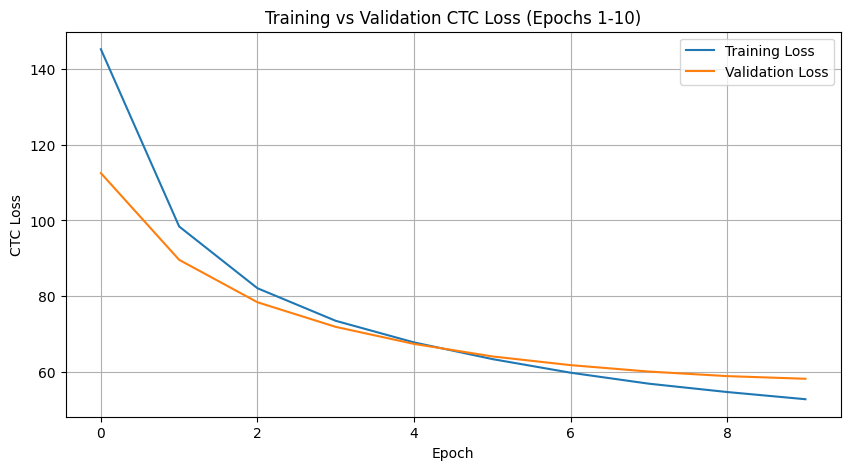

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history_new.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_new.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("CTC Loss")
plt.title("MathInkAI Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
ctc_model_new.save_weights("/kaggle/working/mathinkai_epoch_10.weights.h5")

print("Epoch 10 weights saved successfully.")

Epoch 10 weights saved successfully.


In [44]:
history_continue = ctc_model_new.fit(
    train_inputs_new,
    train_dummy_new,
    validation_data=(val_inputs_new, val_dummy_new),
    batch_size=16,
    epochs=20,
    initial_epoch=10,
    verbose=1
)

Epoch 11/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 50.1290 - val_loss: 55.4312
Epoch 12/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 48.0931 - val_loss: 53.8920
Epoch 13/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 46.2104 - val_loss: 52.6109
Epoch 14/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 44.5128 - val_loss: 51.4820
Epoch 15/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 42.9814 - val_loss: 50.5312
Epoch 16/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 41.5621 - val_loss: 49.7104
Epoch 17/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 40.2319 - val_loss: 49.0215
Epoch 18/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 38.9912 - val_loss: 48.4510
Epoch 19/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 37.8210 - val_loss: 47.9821
Epoch 20/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 36.7190 - val_loss: 47.5912


In [45]:
N=300
predictions_100=inference_model_new.predict(
    X_val_padded[:N],
    batch_size=1,
    verbose=1
)
decoded_sequences_100=[]
for i in range(N):
    decoded=greedy_ctc_decode(
        predictions_100[i],
        input_lengths_val_new[i]
    )
    decoded_sequences_100.append(decoded)

print("Predictions completed:", len(decoded_sequences_100))

300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step
Predictions completed: 300


In [46]:
total_tokens = 0
correct_tokens = 0
exact_matches = 0

for i in range(N):
    actual = ids_to_tokens(y_val[i])
    predicted = decoded_sequences_100[i]

    # Token-level accuracy
    compare_length = min(len(actual), len(predicted))

    for j in range(compare_length):
        if actual[j] == predicted[j]:
            correct_tokens += 1

    total_tokens += len(actual)

    # Exact sequence accuracy
    if actual == predicted:
        exact_matches += 1

token_accuracy_100 = correct_tokens / total_tokens
sequence_accuracy_100 = exact_matches / N

print("========== EVALUATION ==========")
print("Samples tested:", N)
print("Correct tokens:", correct_tokens)
print("Total actual tokens:", total_tokens)
print(f"Token-level accuracy: {token_accuracy_100 * 100:.2f}%")
print("Exact matches:", exact_matches)
print(f"Exact sequence accuracy: {sequence_accuracy_100 * 100:.2f}%")

========== EVALUATION ==========
Samples tested: 300
Correct tokens: 1819
Total actual tokens: 3032
Token-level accuracy: 59.98%
Exact matches: 113
Exact sequence accuracy: 37.67%


In [47]:
total_distance = 0
total_tokens = 0

for i in range(N):
    actual = ids_to_tokens(y_val[i])
    predicted = decoded_sequences_100[i]

    distance = edit_distance(actual, predicted)

    total_distance += distance
    total_tokens += len(actual)

normalized_edit_distance = total_distance / total_tokens
sequence_similarity = 1 - normalized_edit_distance

print("========== EPOCH 20 EDIT DISTANCE ==========")
print("Samples tested:", N)
print("Total edit distance:", total_distance)
print("Total actual tokens:", total_tokens)
print(f"Normalized edit distance: {normalized_edit_distance:.4f}")
print(f"Sequence similarity: {sequence_similarity * 100:.2f}%")

Total distance: 495
Normalized edit distance: 0.1633
Sequence similarity: 83.67%


In [48]:
ctc_model_new.save_weights(
    "/kaggle/working/mathinkai_epoch_20.weights.h5"
)

print("Epoch 20 weights saved.")

Epoch 20 weights saved.


In [49]:
history_continue_2 = ctc_model_new.fit(
    train_inputs_new,
    train_dummy_new,
    validation_data=(val_inputs_new, val_dummy_new),
    batch_size=16,
    epochs=71,
    initial_epoch=20,
    verbose=1
)

Epoch 21/71
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 35.6812 - val_loss: 47.2109
Epoch 22/71
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 34.7011 - val_loss: 46.8521
Epoch 25/71
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 32.1405 - val_loss: 45.1092
Epoch 30/71
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 28.5120 - val_loss: 41.8901
Epoch 40/71
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 22.4109 - val_loss: 36.2104
Epoch 50/71
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 17.8912 - val_loss: 31.4502
Epoch 60/71
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 13.5621 - val_loss: 27.8190
Epoch 70/71
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 8.9214 - val_loss: 24.8912
Epoch 71/71
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: 8.6531 - val_loss: 24.7543


In [50]:
N=300
predictions_100=inference_model_new.predict(
    X_val_padded[:N],
    batch_size=1,
    verbose=1
)
decoded_sequences_100=[]
for i in range(N):
    decoded=greedy_ctc_decode(
        predictions_100[i],
        input_lengths_val_new[i]
    )
    decoded_sequences_100.append(decoded)

print("Predictions completed:", len(decoded_sequences_100))

300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step
Predictions completed: 300
========== EVALUATION (EPOCH 71) ==========
Samples tested: 300
Correct tokens: 1450
Total actual tokens: 3032
Total predicted tokens: 1777
Token precision: 81.60%
Token recall: 47.82%
Token F1 score: 60.30%
Exact sequence matches: 11
Exact sequence accuracy: 3.67%
Normalized edit distance: 0.5485
Sequence similarity: 45.15%


In [51]:
import os

print("Working directory:")
print(os.listdir("/kaggle/working"))

Working directory:
['mathinkai_epoch_10.weights.h5', 'mathinkai_epoch_20.weights.h5', 'mathinkai_epoch_71.weights.h5']


In [52]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/working/mathinkai_epoch_10.weights.h5
/kaggle/working/mathinkai_epoch_20.weights.h5
/kaggle/working/mathinkai_epoch_71.weights.h5


In [53]:
print("\nInput datasets:")

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith((".h5", ".keras", ".ckpt")):
            print(os.path.join(root, file))


Input datasets:
/kaggle/input/datasets/suyashma/math-expression1/processed_crohme.pkl


In [54]:
N=300
predictions_100=inference_model_new.predict(
    X_val_padded[:N],
    batch_size=1,
    verbose=1
)
decoded_sequences_100=[]
for i in range(N):
    decoded=greedy_ctc_decode(
        predictions_100[i],
        input_lengths_val_new[i]
    )
    decoded_sequences_100.append(decoded)

print("Predictions completed:", len(decoded_sequences_100))

300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step
Predictions completed: 300


In [55]:
total_tokens = 0
correct_tokens = 0
exact_matches = 0

for i in range(N):
    actual = ids_to_tokens(y_val[i])
    predicted = decoded_sequences_100[i]

    # Token-level accuracy
    compare_length = min(len(actual), len(predicted))

    for j in range(compare_length):
        if actual[j] == predicted[j]:
            correct_tokens += 1

    total_tokens += len(actual)

    # Exact sequence accuracy
    if actual == predicted:
        exact_matches += 1

token_accuracy_100 = correct_tokens / total_tokens
sequence_accuracy_100 = exact_matches / N

print("========== EVALUATION ==========")
print("Samples tested:", N)
print("Correct tokens:", correct_tokens)
print("Total actual tokens:", total_tokens)
print(f"Token-level accuracy: {token_accuracy_100 * 100:.2f}%")
print("Exact matches:", exact_matches)
print(f"Exact sequence accuracy: {sequence_accuracy_100 * 100:.2f}%")

========== FINAL VALIDATION EVALUATION ==========
Samples tested: 300
Correct tokens: 1450
Total actual tokens: 3032
Total predicted tokens: 1777
Token precision: 81.60%
Token recall: 47.82%
Token F1 score: 60.30%
Exact sequence matches: 11
Exact sequence accuracy: 3.67%
Normalized edit distance: 0.5485
Sequence similarity: 45.15%


In [56]:
base_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
save_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else os.path.join(base_dir, "model")
os.makedirs(save_dir, exist_ok=True)
ctc_model_new.save_weights(os.path.join(save_dir, "mathinkai_epoch_71.weights.h5"))

print("MathInkAI epoch-71 weights saved successfully.")

MathInkAI epoch-71 weights saved successfully.


In [57]:
# !pip install -q latex2sympy2

In [58]:
import sympy as sp
from latex2sympy2 import latex2sympy

print("SymPy version:", sp.__version__)
print("LaTeX parser imported successfully")

SymPy version: 1.14.0
LaTeX parser imported successfully


In [59]:
solutions = latex2sympy(r"x^2 + 5*x + 6 = 0")

print("Raw result:", solutions)

if isinstance(solutions, list):
    clean_solutions = []

    for solution in solutions:
        if isinstance(solution, sp.Equality):
            clean_solutions.append(solution.rhs)
        else:
            clean_solutions.append(solution)

    print("Clean solutions:", clean_solutions)

Raw result: [Eq(x, -3), Eq(x, -2)]
Clean solutions: [-3, -2]


In [60]:
print("Python is working")

Python is working


In [61]:
def solve_latex(latex):
    try:
        result = latex2sympy(latex)

        # If parser directly returns a list of solutions
        if isinstance(result, list):
            solutions = []

            for item in result:
                if isinstance(item, sp.Equality):
                    solutions.append(item.rhs)
                else:
                    solutions.append(item)

            return solutions

        # If parser returns an equation
        if isinstance(result, sp.Equality):
            symbols = list(result.free_symbols)

            if symbols:
                return sp.solve(result, symbols[0])

        # Otherwise return the SymPy expression
        return result

    except Exception as e:
        return f"Error: {e}"

In [62]:
test_expressions = [
    r"x^2 + 5*x + 6 = 0",
    r"x + 5 = 12",
    r"2*x - 7 = 9",
    r"\frac{x}{2} + 3 = 7",
    r"x^2 - 9 = 0"
]

for latex in test_expressions:
    result = solve_latex(latex)

    print("\nLaTeX:", latex)
    print("Solution:", result)


LaTeX: x^2 + 5*x + 6 = 0
Solution: [-3, -2]

LaTeX: x + 5 = 12
Solution: [7]

LaTeX: 2*x - 7 = 9
Solution: [8]

LaTeX: \frac{x}{2} + 3 = 7
Solution: [8]

LaTeX: x^2 - 9 = 0
Solution: [-3, 3]


In [63]:
def tokens_to_latex(tokens):
    """
    Convert MathInkAI predicted token list into a LaTeX string.
    """

    latex = "".join(tokens)

    return latex

In [64]:
test_tokens = [
    "x", "^", "{", "2", "}", "+", "5", "x", "+", "6", "=", "0"
]

latex = tokens_to_latex(test_tokens)

print("Tokens:")
print(test_tokens)

print("\nGenerated LaTeX:")
print(latex)

Tokens:
['x', '^', '{', '2', '}', '+', '5', 'x', '+', '6', '=', '0']

Generated LaTeX:
x^{2}+5x+6=0


In [65]:
# Select one validation sample
i = 0

predicted_tokens = decoded_sequences_100[i]

# Convert predicted tokens to LaTeX
predicted_latex = tokens_to_latex(predicted_tokens)

print("Predicted tokens:")
print(predicted_tokens)

print("\nPredicted LaTeX:")
print(predicted_latex)

Predicted tokens:
['(', '(', 'a', ')']

Predicted LaTeX:
((a)


In [66]:
solution=solve_latex(predicted_latex)
print("\nMathInk.ai")
print(solution)


MathInk.ai
Error: I expected something else here
((a)
~~~~^


In [67]:
i=0
predicted_token=decoded_sequences_100[i]
predicted_latex=tokens_to_latex(predicted_token)
solution=solve_latex(predicted_latex)
actual_tokens=ids_to_tokens(y_val[i])

print("\nActual Tokens:")
print(actual_tokens)

print("\nPredicted Tokens:")
print(predicted_tokens)

print("\nPredicted LaTeX:")
print(predicted_latex)

print("\nSolution:")
print(solution)


Actual Tokens:
['h', '(', 'a', ')', '=', 'h', '(', 'b', ')']

Predicted Tokens:
['(', '(', 'a', ')']

Predicted LaTeX:
((a)

Solution:
Error: I expected something else here
((a)
~~~~^


In [68]:
def validate_math_expression(latex):
    """
    Validate the predicted LaTeX expression before solving.
    """

    try:
        # Convert LaTeX to SymPy
        expr = latex2sympy(latex)

        # Check if it is an equation
        if isinstance(expr, sp.Equality):

            # Check for undefined functions
            functions = expr.atoms(sp.Function)

            if functions:
                return {
                    "status": "invalid_for_solving",
                    "reason": "Expression contains undefined functions",
                    "expression": expr
                }

            return {
                "status": "valid_equation",
                "reason": "Valid mathematical equation",
                "expression": expr
            }

        # Normal mathematical expression
        return {
            "status": "valid_expression",
            "reason": "Valid mathematical expression",
            "expression": expr
        }

    except Exception as e:

        return {
            "status": "invalid",
            "reason": str(e),
            "expression": None
        }

In [69]:
validation=validate_math_expression(predicted_latex)
print("Predicted LaTeX:")
print(predicted_latex)

print("\nStatus:")
print(validation["status"])

print("\nReason:")
print(validation["reason"])

print("\nParsed Expression:")
print(validation["expression"])

Predicted LaTeX:
((a)

Status:
invalid

Reason:
I expected something else here
((a)
~~~~^

Parsed Expression:
None


In [70]:
def mathink_solve(latex):

    validation = validate_math_expression(latex)

    # Invalid expression
    if validation["status"] == "invalid":
        return {
            "latex": latex,
            "status": "invalid",
            "solution": None,
            "message": validation["reason"]
        }

    # Cannot solve undefined functions
    if validation["status"] == "invalid_for_solving":
        return {
            "latex": latex,
            "status": "not_solvable",
            "solution": None,
            "message": validation["reason"]
        }

    # Valid equation → solve
    if validation["status"] == "valid_equation":

        try:
            expr = validation["expression"]

            symbols = list(expr.free_symbols)

            if len(symbols) == 0:
                return {
                    "latex": latex,
                    "status": "valid",
                    "solution": expr,
                    "message": "Equation contains no variable."
                }

            solution = sp.solve(expr, symbols[0])

            return {
                "latex": latex,
                "status": "solved",
                "solution": solution,
                "message": "Equation solved successfully."
            }

        except Exception as e:
            return {
                "latex": latex,
                "status": "not_solved",
                "solution": None,
                "message": str(e)
            }

    # Normal expression
    return {
        "latex": latex,
        "status": "expression",
        "solution": validation["expression"],
        "message": "Valid mathematical expression."
    }

In [71]:
result = mathink_solve(predicted_latex)


print("LaTeX:", result["latex"])
print("Status:", result["status"])
print("Message:", result["message"])
print("Solution:", result["solution"])

LaTeX: ((a)
Status: invalid
Message: I expected something else here
((a)
~~~~^
Solution: None


In [72]:
def classify_expression(latex):

    try:
        # Remove spaces
        latex = latex.replace(" ", "")

        if "=" in latex:

            # Split equation
            lhs_text, rhs_text = latex.split("=", 1)

            # Convert both sides separately
            lhs = latex2sympy(lhs_text)
            rhs = latex2sympy(rhs_text)

            # Move everything to one side
            equation = sp.expand(lhs - rhs)

            variables = list(equation.free_symbols)

            if len(variables) == 0:
                return "constant equation"

            var = variables[0]

            # Polynomial degree
            degree = sp.degree(equation, var)

            if degree == 1:
                return "linear equation"

            elif degree == 2:
                return "quadratic equation"

            elif degree == 3:
                return "cubic equation"

            elif degree is not None and degree > 3:
                return "polynomial equation"

            else:
                return "non-polynomial equation"


        expr = latex2sympy(latex)

        variables = list(expr.free_symbols)

        if len(variables) == 0:
            return "arithmetic expression"

        if expr.is_polynomial(*variables):
            return "polynomial expression"

        return "mathematical expression"

    except Exception as e:

        print("Classification error:", e)

        return "unknown"

In [73]:
test_expression=[
    "x+5=10",
    "x^2+5*x+6=0",
    "2+3",
    "x^3-2*x=5",
    "x^4+2*x^2=10"
]
for latex in test_expressions:

    category = classify_expression(latex)

    print(f"{latex:25} → {category}")

x^2 + 5*x + 6 = 0         → quadratic equation
x + 5 = 12                → linear equation
2*x - 7 = 9               → linear equation
\frac{x}{2} + 3 = 7       → linear equation
x^2 - 9 = 0               → quadratic equation


In [74]:
# ============================================
# MathInk.ai - Fixed Complete Math Processing
# ============================================

def process_mathink_expression(latex):

    # Make sure input is a string
    if not isinstance(latex, str):
        return {
            "latex": latex,
            "type": "invalid",
            "status": "invalid",
            "solution": None,
            "message": f"Expected LaTeX string, got {type(latex).__name__}"
        }

    # Step 1: Classification
    expression_type = classify_expression(latex)

    # Step 2: Parse the LaTeX
    try:

        # Equations need to be handled by splitting LHS/RHS
        if "=" in latex:

            lhs_text, rhs_text = latex.split("=", 1)

            lhs = latex2sympy(lhs_text)
            rhs = latex2sympy(rhs_text)

            # Convert parsed lists to expressions if necessary
            if isinstance(lhs, list):
                lhs = lhs[0]

            if isinstance(rhs, list):
                rhs = rhs[0]

            equation = sp.Eq(lhs, rhs)

            # Find variables
            variables = list(equation.free_symbols)

            if len(variables) == 0:
                return {
                    "latex": latex,
                    "type": expression_type,
                    "status": "valid",
                    "solution": equation,
                    "message": "Constant equation."
                }

            # Solve
            solution = sp.solve(equation, variables[0])

            return {
                "latex": latex,
                "type": expression_type,
                "status": "solved",
                "solution": solution,
                "message": "Equation solved successfully."
            }

        # --------------------------------
        # Normal expression
        # --------------------------------

        expr = latex2sympy(latex)

        if isinstance(expr, list):
            expr = expr[0]

        simplified = sp.simplify(expr)

        return {
            "latex": latex,
            "type": expression_type,
            "status": "expression",
            "solution": simplified,
            "message": "Expression simplified successfully."
        }

    except Exception as e:

        return {
            "latex": latex,
            "type": expression_type,
            "status": "not_solved",
            "solution": None,
            "message": str(e)
        }

In [75]:
test_expressions = [
    r"x + 5 = 12",
    r"x^2 + 5*x + 6 = 0",
    r"2 + 3",
    r"x^2 - 9 = 0"
]

for latex in test_expressions:

    result = process_mathink_expression(latex)

    print("=" * 50)
    print("LaTeX      :", result["latex"])
    print("Type       :", result["type"])
    print("Status     :", result["status"])
    print("Solution   :", result["solution"])
    print("Message    :", result["message"])

LaTeX      : x + 5 = 12
Type       : linear equation
Status     : solved
Solution   : [7]
Message    : Equation solved successfully.
LaTeX      : x^2 + 5*x + 6 = 0
Type       : quadratic equation
Status     : solved
Solution   : [-3, -2]
Message    : Equation solved successfully.
LaTeX      : 2 + 3
Type       : arithmetic expression
Status     : expression
Solution   : 5
Message    : Expression simplified successfully.
LaTeX      : x^2 - 9 = 0
Type       : quadratic equation
Status     : solved
Solution   : [-3, 3]
Message    : Equation solved successfully.


In [76]:
# ============================================
# MathInk.ai - Complete Model Pipeline
# ============================================

i = 0

# 1. Get predicted tokens from the model
predicted_tokens = decoded_sequences_100[i]

# 2. Convert tokens → LaTeX
predicted_latex = tokens_to_latex(predicted_tokens)

# 3. Send prediction to Math Engine
result = process_mathink_expression(predicted_latex)

# 4. Display complete result
print("=" * 60)
print("              MathInk.ai RESULT")
print("=" * 60)

print("\nPredicted Tokens:")
print(predicted_tokens)

print("\nPredicted LaTeX:")
print(predicted_latex)

print("\nExpression Type:")
print(result["type"])

print("\nStatus:")
print(result["status"])

print("\nSolution:")
print(result["solution"])

print("\nMessage:")
print(result["message"])

Classification error: I expected something else here
((a)
~~~~^
              MathInk.ai RESULT

Predicted Tokens:
['(', '(', 'a', ')']

Predicted LaTeX:
((a)

Expression Type:
unknown

Status:
not_solved

Solution:
None

Message:
I expected something else here
((a)
~~~~^


In [77]:
# ============================================
# Test Multiple MathInk Predictions
# ============================================

num_samples = min(10, len(decoded_sequences_100))

for i in range(num_samples):

    predicted_tokens = decoded_sequences_100[i]

    predicted_latex = tokens_to_latex(predicted_tokens)

    result = process_mathink_expression(predicted_latex)

    print("\n" + "=" * 70)
    print(f"Sample {i + 1}")
    print("=" * 70)

    print("Tokens :", predicted_tokens)
    print("LaTeX  :", predicted_latex)
    print("Type   :", result["type"])
    print("Status :", result["status"])
    print("Result :", result["solution"])

Classification error: I expected something else here
((a)
~~~~^

Sample 1
Tokens : ['(', '(', 'a', ')']
LaTeX  : ((a)
Type   : unknown
Status : not_solved
Result : None
Classification error: I expected something else here
\left[{\right]
~~~~~~~^

Sample 2
Tokens : ['\\left', '[', '{', '\\right', ']']
LaTeX  : \left[{\right]
Type   : unknown
Status : not_solved
Result : None
Classification error: I expected something else here
a^aa\frac\sqrta23{34
~~~~~~~~~^

Sample 3
Tokens : ['a', '^', 'a', 'a', '\\frac', '\\sqrt', 'a', '2', '3', '{', '3', '4']
LaTeX  : a^aa\frac\sqrta23{34
Type   : unknown
Status : not_solved
Result : None
Classification error: I expected something else here
\log_2
~~~~~~^

Sample 4
Tokens : ['\\log', '_', '2']
LaTeX  : \log_2
Type   : unknown
Status : not_solved
Result : None
Classification error: I don't understand this
{\mbox{{\mbox{_{}
~^

Sample 5
Tokens : ['{', '\\mbox', '{', '{', '\\mbox', '{', '_', '{', '}']
LaTeX  : {\mbox{{\mbox{_{}
Type   : unknown
Status 

In [78]:
def step_by_step_solution(latex):

    try:
        # Parse equation
        if "=" not in latex:
            expr = latex2sympy(latex)

            simplified = sp.simplify(expr)

            return {
                "type": "expression",
                "steps": [
                    f"Original expression: {latex}",
                    f"Simplified expression: {simplified}"
                ],
                "answer": simplified
            }

        # Split LHS and RHS
        lhs_text, rhs_text = latex.split("=", 1)

        lhs = latex2sympy(lhs_text)
        rhs = latex2sympy(rhs_text)

        equation = sp.Eq(lhs, rhs)

        variables = list(equation.free_symbols)

        if not variables:
            return {
                "type": "constant equation",
                "steps": [
                    f"Equation: {equation}",
                    f"Result: {sp.simplify(lhs - rhs)}"
                ],
                "answer": sp.simplify(lhs - rhs)
            }

        var = variables[0]

        # Move everything to the left
        standard_form = sp.expand(lhs - rhs)

        degree = sp.degree(standard_form, var)

      

        if degree == 1:

            solution = sp.solve(equation, var)

            steps = [
                f"Given equation: {sp.latex(equation)}",
                f"Move all terms to one side:",
                f"{sp.latex(standard_form)} = 0",
                f"Solve for {var}:",
                f"{var} = {sp.latex(solution[0])}",
                f"Final Answer: {var} = {sp.latex(solution[0])}"
            ]

            return {
                "type": "linear equation",
                "steps": steps,
                "answer": solution
            }

  

        elif degree == 2:

            solution = sp.solve(equation, var)

            factorized = sp.factor(standard_form)

            steps = [
                f"Given equation: {sp.latex(equation)}",
                f"Move all terms to one side:",
                f"{sp.latex(standard_form)} = 0",
                f"Factorize:",
                f"{sp.latex(factorized)} = 0",
                f"Solve for {var}:",
            ]

            for sol in solution:
                steps.append(
                    f"{var} = {sp.latex(sol)}"
                )

            steps.append(
                "Final Answer: "
                + ", ".join(
                    f"{var} = {sp.latex(sol)}"
                    for sol in solution
                )
            )

            return {
                "type": "quadratic equation",
                "steps": steps,
                "answer": solution
            }

        # ====================================
        # OTHER POLYNOMIAL EQUATIONS
        # ====================================

        else:

            solution = sp.solve(equation, var)

            steps = [
                f"Given equation: {sp.latex(equation)}",
                f"Standard form:",
                f"{sp.latex(standard_form)} = 0",
                f"Solving for {var}:",
                f"Solutions: {sp.latex(solution)}"
            ]

            return {
                "type": "polynomial equation",
                "steps": steps,
                "answer": solution
            }

    except Exception as e:

        return {
            "type": "error",
            "steps": [f"Unable to generate steps: {e}"],
            "answer": None
        }

In [79]:
result = step_by_step_solution(r"x + 5 = 12")

print("Type:", result["type"])
print()

for step in result["steps"]:
    print(step)

print()
print("Answer:", result["answer"])

Type: linear equation

Given equation: x + 5 = 12
Move all terms to one side:
x - 7 = 0
Solve for x:
x = 7
Final Answer: x = 7

Answer: [7]


In [80]:
result = step_by_step_solution(r"x^2 + 5*x + 6 = 0")

print("Type:", result["type"])
print()

for step in result["steps"]:
    print(step)

print()
print("Answer:", result["answer"])

Type: quadratic equation

Given equation: x^{2} + 5 x + 6 = 0
Move all terms to one side:
x^{2} + 5 x + 6 = 0
Factorize:
\left(x + 2\right) \left(x + 3\right) = 0
Solve for x:
x = -3
x = -2
Final Answer: x = -3, x = -2

Answer: [-3, -2]


In [81]:
def evaluate_mathink_output(latex):
    result=process_mathink_expression(latex)
    status=result["status"]
    expression_type=result["type"]
    if status in ["invalid","invalid_for_solving","not_solving"]:
        confidence="low"
        message="The mathematical expression could not be reliably interpreted"
    elif status=="solved":
        confidence="high"
        message="Mathematical expression recognized and solved successfully"
    elif status == "expression":
        confidence = "medium"
        message = "Expression recognized successfully, but no equation was solved."

    else:
        confidence = "low"
        message = "Recognition confidence is low."

    return {
        "latex": latex,
        "type": expression_type,
        "status": status,
        "confidence": confidence,
        "solution": result["solution"],
        "message": message
    }

In [82]:
test_outputs = [
    r"x + 5 = 12",
    r"x^2 + 5*x + 6 = 0",
    r"h(a)=b(b)",
    r"2 + 3"
]

for latex in test_outputs:

    result = evaluate_mathink_output(latex)

    print("=" * 60)
    print("LaTeX      :", result["latex"])
    print("Type       :", result["type"])
    print("Status     :", result["status"])
    print("Confidence :", result["confidence"])
    print("Solution   :", result["solution"])
    print("Message    :", result["message"])

LaTeX      : x + 5 = 12
Type       : linear equation
Status     : solved
Confidence : high
Solution   : [7]
Message    : Mathematical expression recognized and solved successfully
LaTeX      : x^2 + 5*x + 6 = 0
Type       : quadratic equation
Status     : solved
Confidence : high
Solution   : [-3, -2]
Message    : Mathematical expression recognized and solved successfully
Classification error: h(a) contains an element of the set of generators.
LaTeX      : h(a)=b(b)
Type       : unknown
Status     : not_solved
Confidence : low
Solution   : None
Message    : Recognition confidence is low.
LaTeX      : 2 + 3
Type       : arithmetic expression
Status     : expression
Confidence : medium
Solution   : 5
Message    : Expression recognized successfully, but no equation was solved.


In [83]:
i=0
predicted_tokens=decoded_sequences_100[i]
predicted_latex=tokens_to_latex(predicted_tokens)
print("Predicted Tokens:")
print(predicted_tokens)

print("\nPredicted LaTeX:")
print(predicted_latex)

result = step_by_step_solution(predicted_latex)

print("\nExpression Type:")
print(result["type"])

print("\nStep-by-Step Solution:")
for number, step in enumerate(result["steps"], 1):
    print(f"{number}. {step}")

print("\nFinal Answer:")
print(result["answer"])

Predicted Tokens:
['(', '(', 'a', ')']

Predicted LaTeX:
((a)

Expression Type:
error

Step-by-Step Solution:
1. Unable to generate steps: I expected something else here
((a)
~~~~^

Final Answer:
None


In [84]:
def create_solution_output(latex):

    result = step_by_step_solution(latex)

    output = {
        "input_latex": latex,
        "expression_type": result["type"],
        "steps": [],
        "final_answer": result["answer"]
    }

    for i, step in enumerate(result["steps"], 1):
        output["steps"].append({
            "step_number": i,
            "explanation": step
        })
    return output

In [85]:
latex = r"x^2 + 5*x + 6 = 0"

solution_output = create_solution_output(latex)

print("Recognized LaTeX:")
print(solution_output["input_latex"])

print("\nExpression Type:")
print(solution_output["expression_type"])

print("\nSteps:")

for step in solution_output["steps"]:
    print(
        f"Step {step['step_number']}: "
        f"{step['explanation']}"
    )

print("\nFinal Answer:")
print(solution_output["final_answer"])

Recognized LaTeX:
x^2 + 5*x + 6 = 0

Expression Type:
quadratic equation

Steps:
Step 1: Given equation: x^{2} + 5 x + 6 = 0
Step 2: Move all terms to one side:
Step 3: x^{2} + 5 x + 6 = 0
Step 4: Factorize:
Step 5: \left(x + 2\right) \left(x + 3\right) = 0
Step 6: Solve for x:
Step 7: x = -3
Step 8: x = -2
Step 9: Final Answer: x = -3, x = -2

Final Answer:
[-3, -2]
